# Data Preprocessing & Input Pipeline Preparation

### 🎯 Goal of This Notebook
<pre>
The goal of this notebook is to preprocess crop leaf images and build efficient, Keras-compatible input pipelines
for training, validation, and testing of CNN models.
</pre>
### This notebook ensures:
 - All images are uniformly resized and normalized
 - Data augmentation is applied correctly (train only)
 - Class labels are encoded properly
 - Data loaders are optimized for performance and memory usage


## Clone the GitHub Repository
### 📌 Purpose
<pre>
 - To obtain the complete project structure locally for exploration and experimentation.
</pre>

In [1]:
# Clone the Repository
!git clone https://github.com/sabin74/Agriculture-Crop-Disease-Detection-Advisory-System.git


Cloning into 'Agriculture-Crop-Disease-Detection-Advisory-System'...
remote: Enumerating objects: 97299, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 97299 (delta 11), reused 26 (delta 9), pack-reused 97220 (from 1)
Receiving objects: 100% (97299/97299), 1.78 GiB | 26.94 MiB/s, done.
Resolving deltas: 100% (521/521), done.
Updating files: 100% (94772/94772), done.


In [2]:
# Set Project Root
import os
os.chdir("/content/Agriculture-Crop-Disease-Detection-Advisory-System")
print("Current Directory: ", os.getcwd())

Current Directory:  /content/Agriculture-Crop-Disease-Detection-Advisory-System


## Import Required Libraries
### 📌 Purpose

Load all libraries required for image preprocessing, input pipeline preparation, augmentation, and sanity checks.

In [3]:
# System & Path Handling
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Numerical Computation
import numpy as np
import pandas as pd

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration & Utilities
import json
import yaml
from sklearn.utils import class_weight

# Set Visualization Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [4]:
# Environment Verification
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
Keras Version: 3.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##Define Dataset Paths
### 📌 Purpose

Centralize all dataset directory paths in one place so they can be reused consistently throughout the notebook.

In [5]:
# Define Dataset Paths
BASE_DIR = Path("Modeling/Crop Disease Dataset")

TRAIN_DIR = BASE_DIR / "train"
VALID_DIR = BASE_DIR / "valid"
TEST_DIR = BASE_DIR / "test"

print("DATASET PATHS:")
print(f"  Training: {TRAIN_DIR}")
print(f"  Validation: {VALID_DIR}")
print(f"  Test: {TEST_DIR}")


DATASET PATHS:
  Training: Modeling/Crop Disease Dataset/train
  Validation: Modeling/Crop Disease Dataset/valid
  Test: Modeling/Crop Disease Dataset/test


In [7]:
# Verify directories exist
print("\nVERIFICATION:")
for dir_name, dir_path in [("Train", TRAIN_DIR), ("Validation", VALID_DIR), ("Test", TEST_DIR)]:
    if dir_path.exists():
        print(f"  {dir_name}: Found")
    else:
        print(f"  {dir_name}: NOT FOUND!")


VERIFICATION:
  Train: Found
  Validation: Found
  Test: Found


##  Load Previous Analysis Results

In [8]:
# Load analysis results from Notebook 1
ANALYSIS_DIR = Path("Modeling/reports/analysis_results")

if ANALYSIS_DIR.exists():
    # Load class distribution
    train_dist_df = pd.read_csv(ANALYSIS_DIR / "train_class_distribution.csv")
    val_dist_df = pd.read_csv(ANALYSIS_DIR / "val_class_distribution.csv")

    # Load dataset summary
    with open(ANALYSIS_DIR / "dataset_summary.json", "r") as f:
        dataset_summary = json.load(f)

    print(" Previous analysis results loaded!")
    print(f" Total Classes: {dataset_summary['dataset_info']['total_classes']}")
    print(f" Total Training Images: {dataset_summary['dataset_info']['total_images']:,}")
    print(f" Imbalance Ratio: {dataset_summary['image_statistics']['imbalance_ratio']:.1f}x")
else:
    print(" Previous analysis results not found. Creating new analysis...")
    # Create minimal analysis if not found
    train_dist_df = None
    dataset_summary = None

 Previous analysis results loaded!
 Total Classes: 45
 Total Training Images: 70,780
 Imbalance Ratio: 43.9x


## Define Image Parameters
### 📌 Purpose

Standardize image inputs so all CNN models receive uniform data, ensuring:

 - Consistent tensor shapes
 - Model compatibility
 - Stable training behavior

In [9]:
# Image Parameters for CNN
IMAGE_SIZE = (224, 224)    # Standard size for MobileNetV2, ResNet50
BATCH_SIZE = 32            # Optimized for Colab memory
COLOR_MODE = 'rgb'         # 3-channel color images

print(" IMAGE PARAMETERS:")
print(f"\n  Size: {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]} pixels")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Color Mode: {COLOR_MODE}")
print(f"  Channels: 3 (RGB)")

 IMAGE PARAMETERS:

  Size: 224x224 pixels
  Batch Size: 32
  Color Mode: rgb
  Channels: 3 (RGB)


## Calculate Class Weights (Handle Imbalance)

In [10]:
def calculate_class_weights():
    """
    Calculate class weights to handle dataset imbalance
    """
    print(" CALCULATING CLASS WEIGHTS...")

    # Count images per class
    class_counts = {}
    class_folders = [f for f in TRAIN_DIR.iterdir() if f.is_dir()]

    for folder in class_folders:
        class_name = folder.name
        image_count = len([f for f in folder.iterdir()
                          if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
        class_counts[class_name] = image_count

    # Convert to list for sklearn
    classes = list(class_counts.keys())
    class_values = list(class_counts.values())

    # Generate indices for each class
    class_indices = {}
    train_labels = []

    for idx, class_name in enumerate(classes):
        class_indices[class_name] = idx
        # Add class index repeated for each sample
        train_labels.extend([idx] * class_counts[class_name])

    # Calculate class weights
    train_labels_array = np.array(train_labels)
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels_array),
        y=train_labels_array
    )

    # Convert to dictionary format
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    print(f" Class weights calculated for {len(classes)} classes")

    # Show weight distribution
    print("\n WEIGHT DISTRIBUTION (Top 5 heaviest weights):")
    sorted_weights = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)
    for idx, weight in sorted_weights[:5]:
        class_name = classes[idx]
        count = class_counts[class_name]
        print(f"  {class_name[:30]:30} → {count:4d} samples, weight: {weight:.2f}")

    return class_indices, class_weight_dict



In [11]:
# Calculate class weights
class_indices, class_weight_dict = calculate_class_weights()

 CALCULATING CLASS WEIGHTS...
 Class weights calculated for 45 classes

 WEIGHT DISTRIBUTION (Top 5 heaviest weights):
  Sugarcane__RedRust             →   75 samples, weight: 20.97
  Coffee__NoRust                 →  206 samples, weight: 7.64
  Banana__Panama_Disease         →  248 samples, weight: 6.34
  Sugarcane__Yellow_Rust         →  383 samples, weight: 4.11
  Sugarcane__Mosaic              →  462 samples, weight: 3.40


## Data Augmentation Strategy
### 📌 Purpose

Increase data diversity and model generalization by applying realistic transformations only to training images.

In [12]:
# Standard augmentation for all classes
train_datagen = ImageDataGenerator(
    rescale=1./255,                # Normalize to [0, 1]
    rotation_range=20,             # Random rotation
    width_shift_range=0.1,         # Horizontal shift
    height_shift_range=0.1,        # Vertical shift
    zoom_range=0.1,                # Random zoom
    horizontal_flip=True,          # Random horizontal flip
    brightness_range=[0.9, 1.1],   # Random brightness
    fill_mode='nearest'            # Fill missing pixels
)

In [13]:
# Stronger augmentation for minority classes
strong_aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,             # More rotation
    width_shift_range=0.2,         # More horizontal shift
    height_shift_range=0.2,        # More vertical shift
    zoom_range=0.2,                # More zoom
    horizontal_flip=True,
    vertical_flip=True,            # Additional vertical flip
    brightness_range=[0.8, 1.2],   # Wider brightness range
    shear_range=0.2,               # Shear transformation
    fill_mode='nearest'
)

In [14]:
# No augmentation for validation/test
valid_test_datagen = ImageDataGenerator(
    rescale=1./255  # Only normalization
)

In [15]:
print("CREATING DATA AUGMENTATION STRATEGY...")
print("\n AUGMENTATION SETTINGS:")
print("  • Standard Augmentation:")
print("    - Rotation: ±20°")
print("    - Shift: ±10%")
print("    - Zoom: ±10%")
print("    - Horizontal Flip: Yes")
print("  • Strong Augmentation (for minority classes):")
print("    - Rotation: ±40°")
print("    - Shift: ±20%")
print("    - Zoom: ±20%")
print("    - Horizontal & Vertical Flip")
print("  • Validation/Test: Only normalization")

CREATING DATA AUGMENTATION STRATEGY...

 AUGMENTATION SETTINGS:
  • Standard Augmentation:
    - Rotation: ±20°
    - Shift: ±10%
    - Zoom: ±10%
    - Horizontal Flip: Yes
  • Strong Augmentation (for minority classes):
    - Rotation: ±40°
    - Shift: ±20%
    - Zoom: ±20%
    - Horizontal & Vertical Flip
  • Validation/Test: Only normalization


## Create Training Data Generator
### 📌 Purpose

Load training images dynamically from disk, apply data augmentation, and generate:

 - Image batches
 - One-hot encoded class labels

In [16]:
# Training generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

Found 74880 images belonging to 45 classes.


In [17]:
# Validation generator
val_generator = valid_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,  # Important: Don't shuffle validation
    seed=42
)

Found 19804 images belonging to 45 classes.


In [18]:
print("🔄 CREATING DATA GENERATORS...")
print(f"  Training: {train_generator.samples:,} images, {train_generator.num_classes} classes")
print(f"  Validation: {val_generator.samples:,} images, {val_generator.num_classes} classes")



🔄 CREATING DATA GENERATORS...
  Training: 74,880 images, 45 classes
  Validation: 19,804 images, 45 classes


In [19]:
# Verify class consistency
if train_generator.num_classes == val_generator.num_classes:
    print(f"  Class counts match: {train_generator.num_classes}")
else:
    print(f"  Class count mismatch!")

  Class counts match: 45


## Save Class Information

In [20]:
# Create configuration directory
CONFIG_DIR = Path("Modeling/configs")
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

# Save class indices (from generator)
with open(CONFIG_DIR / "class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f, indent=4)

# Save reverse mapping
reverse_mapping = {v: k for k, v in train_generator.class_indices.items()}
with open(CONFIG_DIR / "class_names.json", "w") as f:
    json.dump(reverse_mapping, f, indent=4)

# Save class weights
with open(CONFIG_DIR / "class_weights.json", "w") as f:
    json.dump(class_weight_dict, f, indent=4)

print(" CLASS INFORMATION SAVED:")
print(f"  - Class indices: {CONFIG_DIR / 'class_indices.json'}")
print(f"  - Class names: {CONFIG_DIR / 'class_names.json'}")
print(f"  - Class weights: {CONFIG_DIR / 'class_weights.json'}")

 CLASS INFORMATION SAVED:
  - Class indices: Modeling/configs/class_indices.json
  - Class names: Modeling/configs/class_names.json
  - Class weights: Modeling/configs/class_weights.json


## Visualize Augmented Images

In [21]:
def visualize_augmented_images(generator, title, save_path):
    """
    Visualize augmented images from generator
    """
    # Get a batch of images
    images, labels = next(generator)

    fig = plt.figure(figsize=(15, 10))

    for i in range(12):  # Show 12 images
        ax = plt.subplot(3, 4, i + 1)

        # Display image ( normalized to [0, 1])
        plt.imshow(images[i])

        # Get class name
        class_idx = np.argmax(labels[i])
        class_name = reverse_mapping.get(class_idx, f"Class {class_idx}")

        # Shorten long class names
        if len(class_name) > 25:
            class_name = class_name[:22] + "..."

        plt.title(f"{class_name}\nIdx: {class_idx}", fontsize=9)
        plt.axis('off')

    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()

    # Save figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    return images.shape, labels.shape

VISUALIZING AUGMENTED IMAGES...


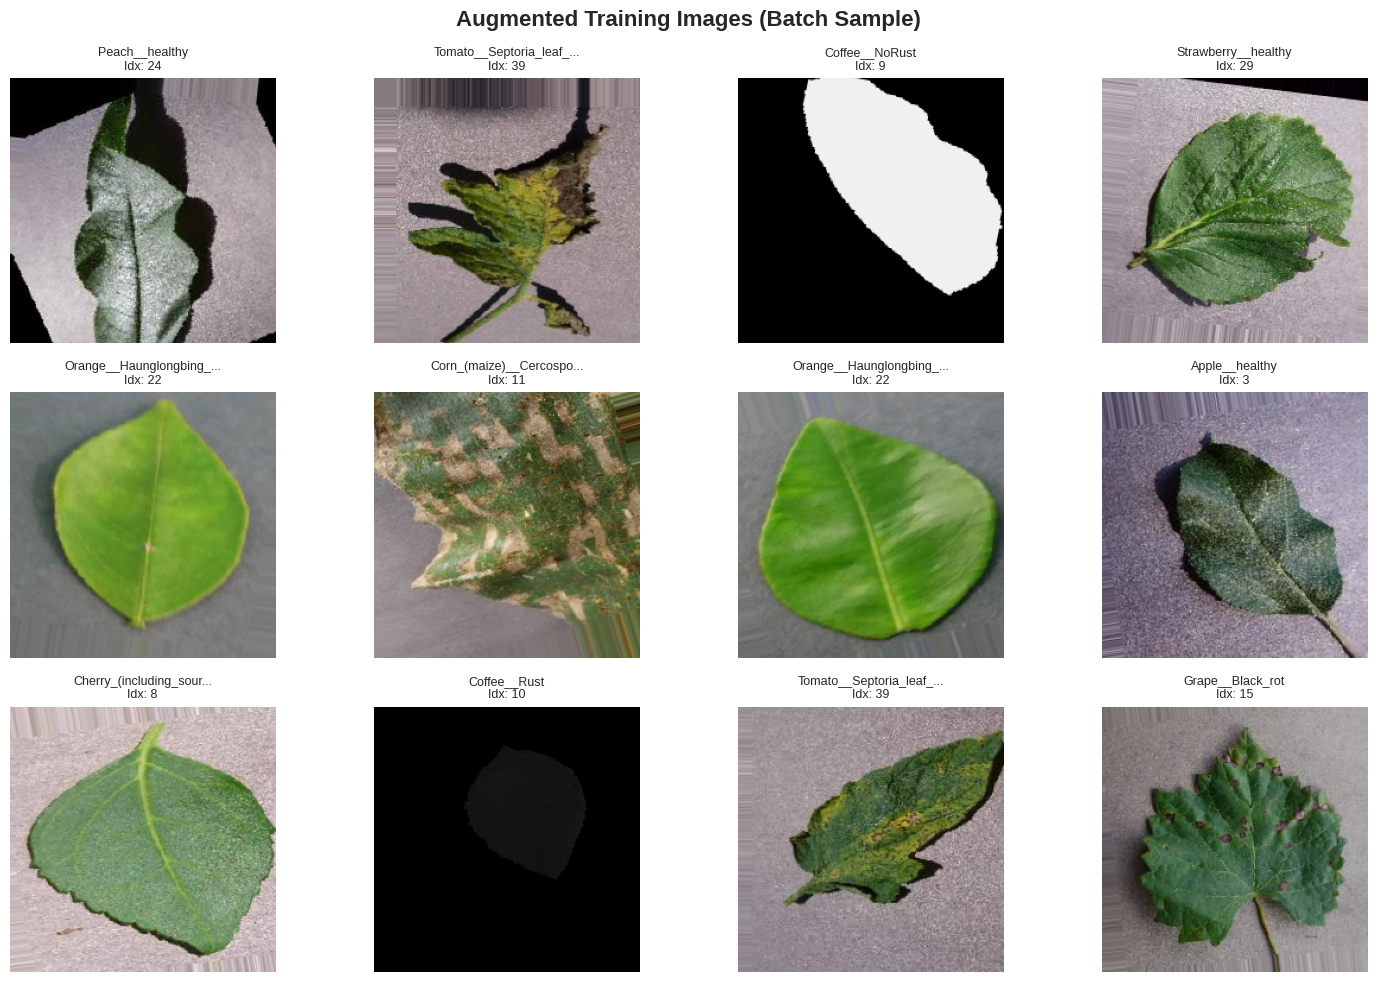

Training batch shape: (32, 224, 224, 3) images, (32, 45) labels


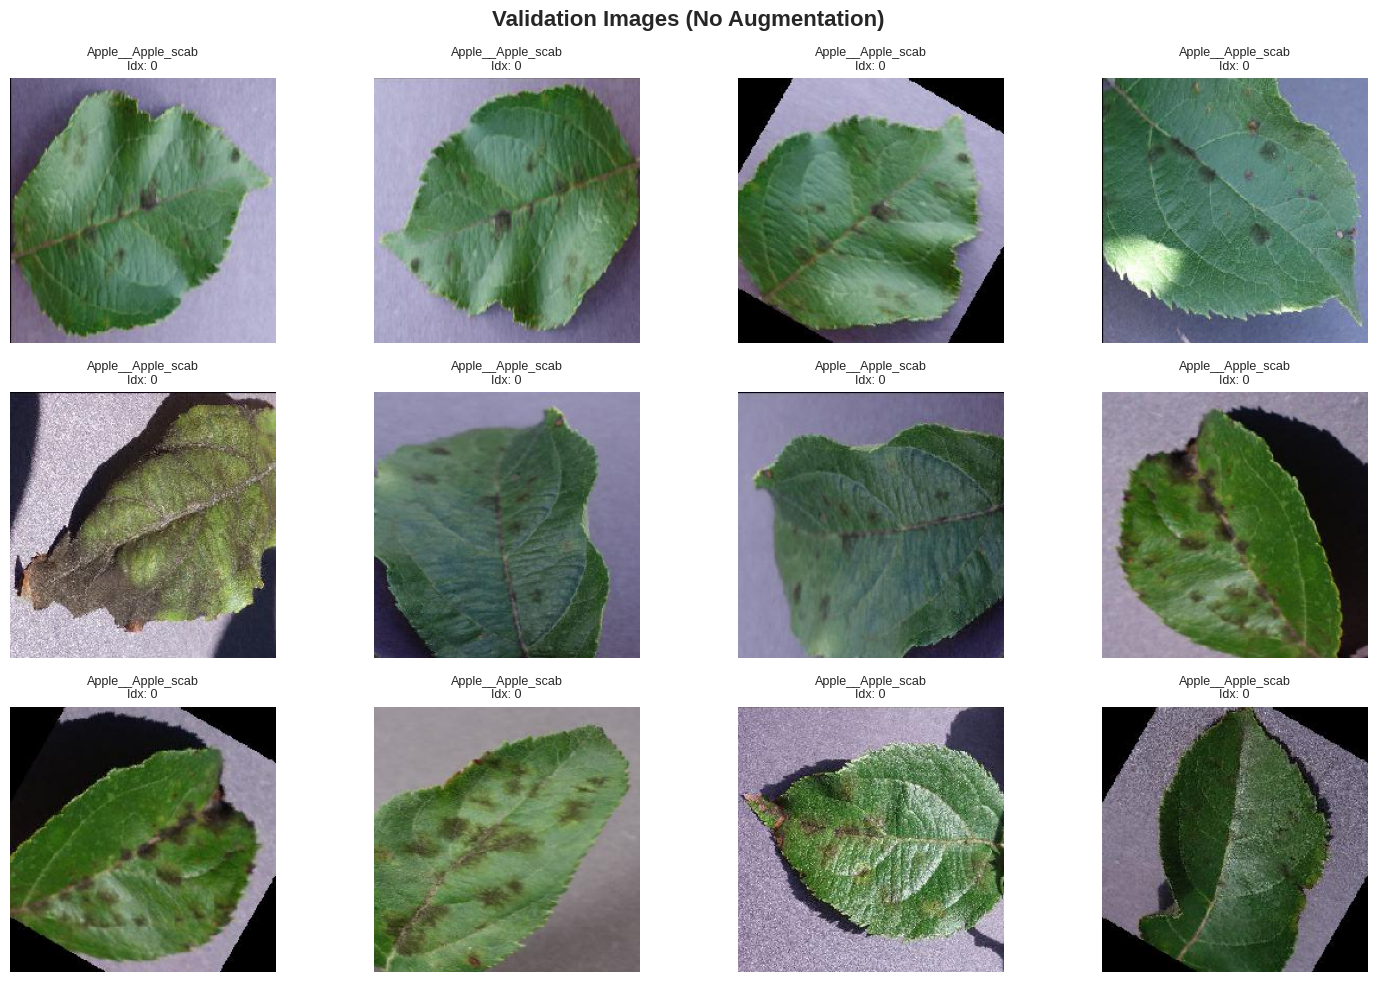

Validation batch shape: (32, 224, 224, 3) images, (32, 45) labels


In [22]:
print("VISUALIZING AUGMENTED IMAGES...")

# Create visualization directory
VIZ_DIR = Path("Modeling/reports/visualizations/preprocessing")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Visualize training images
train_shape = visualize_augmented_images(
    train_generator,
    "Augmented Training Images (Batch Sample)",
    VIZ_DIR / "augmented_training_images.png"
)

print(f"Training batch shape: {train_shape[0]} images, {train_shape[1]} labels")

# Visualize validation images
val_shape = visualize_augmented_images(
    val_generator,
    "Validation Images (No Augmentation)",
    VIZ_DIR / "validation_images.png"
)

print(f"Validation batch shape: {val_shape[0]} images, {val_shape[1]} labels")

## Create Configuration File

In [23]:
# Create comprehensive configuration
config = {
    "paths": {
        "train_dir": str(TRAIN_DIR),
        "val_dir": str(VALID_DIR),
        "test_dir": str(TEST_DIR),
        "config_dir": str(CONFIG_DIR),
        "viz_dir": str(VIZ_DIR)
    },
    "image_parameters": {
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "color_mode": COLOR_MODE,
        "normalization": "1./255"
    },
    "dataset_info": {
        "num_classes": train_generator.num_classes,
        "train_samples": train_generator.samples,
        "val_samples": val_generator.samples,
        "steps_per_epoch": train_generator.samples // BATCH_SIZE,
        "validation_steps": val_generator.samples // BATCH_SIZE
    },
    "augmentation": {
        "standard": {
            "rotation_range": 20,
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "zoom_range": 0.1,
            "horizontal_flip": True,
            "brightness_range": [0.9, 1.1]
        },
        "strong": {
            "rotation_range": 40,
            "width_shift_range": 0.2,
            "height_shift_range": 0.2,
            "zoom_range": 0.2,
            "horizontal_flip": True,
            "vertical_flip": True,
            "brightness_range": [0.8, 1.2],
            "shear_range": 0.2
        }
    },
    "class_info": {
        "total_classes": train_generator.num_classes,
        "class_indices_file": "class_indices.json",
        "class_names_file": "class_names.json",
        "class_weights_file": "class_weights.json"
    },
    "metadata": {
        "created": pd.Timestamp.now().isoformat(),
        "tensorflow_version": tf.__version__,
        "keras_version": keras.__version__
    }
}


In [24]:

# Save configuration
with open(CONFIG_DIR / "preprocessing_config.json", "w") as f:
    json.dump(config, f, indent=4)

with open(CONFIG_DIR / "preprocessing_config.yaml", "w") as f:
    yaml.dump(config, f, indent=2, default_flow_style=False)

print("CONFIGURATION SAVED:")
print(f"  - JSON: {CONFIG_DIR / 'preprocessing_config.json'}")
print(f"  - YAML: {CONFIG_DIR / 'preprocessing_config.yaml'}")



CONFIGURATION SAVED:
  - JSON: Modeling/configs/preprocessing_config.json
  - YAML: Modeling/configs/preprocessing_config.yaml


In [25]:
# Display summary
print("CONFIGURATION SUMMARY:")
print(f"\nImage Processing:")
print(f"  - Size: {config['image_parameters']['image_size']}")
print(f"  - Batch: {config['image_parameters']['batch_size']}")
print(f"  - Color: {config['image_parameters']['color_mode']}")
print(f"\nDataset:")
print(f"  - Classes: {config['dataset_info']['num_classes']}")
print(f"  - Train: {config['dataset_info']['train_samples']:,}")
print(f"  - Validation: {config['dataset_info']['val_samples']:,}")
print(f"\nAugmentation:")
print(f"  - Rotation: ±{config['augmentation']['standard']['rotation_range']}°")
print(f"  - Flip: Horizontal")
print(f"  - Zoom: ±{config['augmentation']['standard']['zoom_range']*100}%")

CONFIGURATION SUMMARY:

Image Processing:
  - Size: (224, 224)
  - Batch: 32
  - Color: rgb

Dataset:
  - Classes: 45
  - Train: 74,880
  - Validation: 19,804

Augmentation:
  - Rotation: ±20°
  - Flip: Horizontal
  - Zoom: ±10.0%


## Prepare for Model Training

In [26]:
print(" PREPARING FOR MODEL TRAINING...")

# Calculate steps per epoch
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = val_generator.samples // BATCH_SIZE

print(f"\n TRAINING PARAMETERS:")
print(f"  - Steps per epoch: {steps_per_epoch}")
print(f"  - Validation steps: {validation_steps}")
print(f"  - Total batches per epoch: {steps_per_epoch * BATCH_SIZE:,} images")
print(f"  - Class weights calculated: {len(class_weight_dict)} classes")


 PREPARING FOR MODEL TRAINING...

 TRAINING PARAMETERS:
  - Steps per epoch: 2340
  - Validation steps: 618
  - Total batches per epoch: 74,880 images
  - Class weights calculated: 45 classes


In [27]:
# Display class distribution
print(f"\nCLASS DISTRIBUTION (Sample):\n")
for i, (class_name, class_idx) in enumerate(list(train_generator.class_indices.items())[:5]):
    weight = class_weight_dict.get(class_idx, 1.0)
    print(f"  {class_name[:30]:30} → Index: {class_idx:2d}, Weight: {weight:.2f}")

print("\nPREPROCESSING COMPLETE!")
print("  Data generators are ready for model training.")
print("  Class weights calculated to handle imbalance.")
print("  All configurations saved for reproducibility.")


CLASS DISTRIBUTION (Sample):

  Apple__Apple_scab              → Index:  0, Weight: 6.34
  Apple__Black_rot               → Index:  1, Weight: 0.83
  Apple__Cedar_apple_rust        → Index:  2, Weight: 0.82
  Apple__healthy                 → Index:  3, Weight: 0.93
  Banana__Healthy_Leaf           → Index:  4, Weight: 0.82

PREPROCESSING COMPLETE!
  Data generators are ready for model training.
  Class weights calculated to handle imbalance.
  All configurations saved for reproducibility.


## Save and Download Results

In [28]:
# Download both configs and reports directories
import shutil
from google.colab import files
from datetime import datetime

print("CREATING DOWNLOAD PACKAGE...")

# Create timestamp for unique filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f"crop_disease_preprocessing_{timestamp}"

# 1. Paths to the folders you want to zip
folders_to_zip = [
    '/content/Agriculture-Crop-Disease-Detection-Advisory-System/Modeling/configs',
    '/content/Agriculture-Crop-Disease-Detection-Advisory-System/Modeling/reports'
]

# 2. Create a temporary directory to combine all folders
import tempfile
import os

with tempfile.TemporaryDirectory() as temp_dir:
    # Copy all folders to temporary directory
    for folder_path in folders_to_zip:
        if os.path.exists(folder_path):
            folder_name = os.path.basename(folder_path)
            dest_path = os.path.join(temp_dir, folder_name)
            shutil.copytree(folder_path, dest_path)
            print(f"  Added: {folder_name}")
        else:
            print(f"  Not found: {folder_path}")

    # 3. Create the zip archive from temporary directory
    shutil.make_archive(output_filename, 'zip', temp_dir)

print(f"\nZip file created: {output_filename}.zip")

# 4. Trigger the download
files.download(f'{output_filename}.zip')

print("Download started! Check your browser downloads.")

CREATING DOWNLOAD PACKAGE...
  Added: configs
  Added: reports

Zip file created: crop_disease_preprocessing_20260128_075534.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! Check your browser downloads.
